### Explanatory Data Analysis (EDA)

Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
import os

Raw Data

In [3]:
movies = pd.read_csv('../data/raw/movies.csv')
ratings = pd.read_csv('../data/raw/ratings.csv')
tags = pd.read_csv('../data/raw/tags.csv')
links = pd.read_csv('../data/raw/links.csv')

### Data ingestion and preprocessing

In [4]:
display(movies.head(5))

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
movies['release_year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['release_year'] = pd.to_numeric(movies['release_year'], errors='coerce')
movies['title_clean'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

In [6]:
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
tags['datetime'] = pd.to_datetime(tags['timestamp'], unit='s')

In [7]:
ratings['rating_year'] = ratings['datetime'].dt.year
ratings['rating_month'] = ratings['datetime'].dt.month

In [8]:
df = ratings.merge(movies, on='movieId', how='left')

In [9]:
missing_data = df.isnull().sum()
print("\nMissing Values per Column:")
print(missing_data[missing_data > 0])


Missing Values per Column:
release_year    18
dtype: int64


In [10]:
duplicates = df.duplicated(subset=['userId', 'movieId']).sum()
print(f"\nDuplicates Found: {duplicates}")


Duplicates Found: 0


In [11]:
print("\nProcessed Master DataFrame Preview:")
display(df[['userId', 'title_clean', 'release_year', 'rating', 'datetime']].head())


Processed Master DataFrame Preview:


,userId,title_clean,release_year,rating,datetime
0,1,Toy Story,1995.0,4.0,2000-07-30 18:45:03
1,1,Grumpier Old Men,1995.0,4.0,2000-07-30 18:20:47
2,1,Heat,1995.0,4.0,2000-07-30 18:37:04
3,1,Seven (a.k.a. Se7en),1995.0,5.0,2000-07-30 19:03:35
4,1,"Usual Suspects, The",1995.0,5.0,2000-07-30 18:48:51


In [12]:
processed_dir = '../data/processed'
df.to_parquet(f'{processed_dir}/master_data.parquet', index=False)
movies.to_parquet(f'{processed_dir}/movies_clean.parquet', index=False)
ratings.to_parquet(f'{processed_dir}/ratings_clean.parquet', index=False)

### **Univariate Analysis**

#### Rating distribution

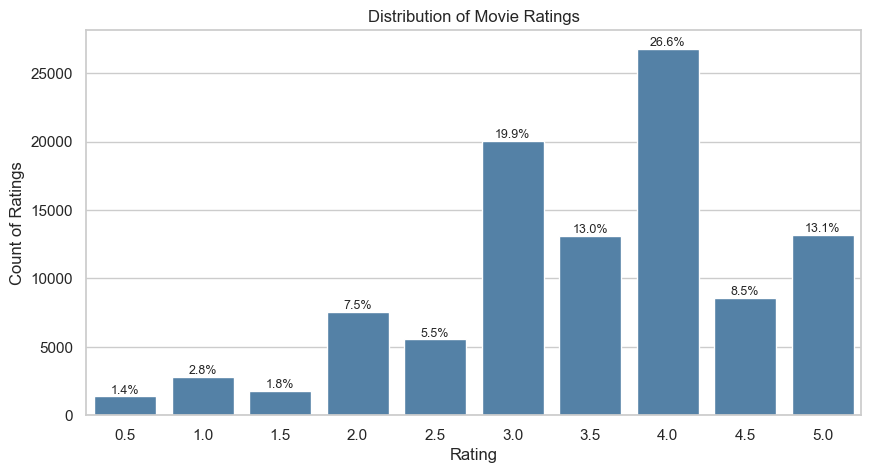

In [13]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='rating', color='steelblue')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count of Ratings')
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9)
plt.show()

Based on the distribution of the movie ratings, we can observe several patterns
1. Postivity bias: The ratings are not normally distributed. The platform leans heavily positive, with the vast majority of ratings ($\approx 81\%$) falling at $3.0$ stars or higher. The single most common rating is $4.0$ ($26.6\%$). This suggests that users predominantly rate movies they already suspect they will enjoy, or they simply avoid finishing and rating bad movies.
2. Full-star preference: There is a clear psychological bias toward whole numbers. Users are significantly more likely to give a $3.0$, $4.0$, or $5.0$ than they are to use the half-star ratings ($2.5$, $3.5$, $4.5$).

Conclusion for futher work:
Because of the leftward skewness, an absolute rating of $3.0$ is actually considered a below-average score. If we feed raw ratings directly into a Matrix Factorization model (like SVD), it will struggle to differentiate true preferences. Therefore, before training, we must implement baseline predictors. We need to center the ratings by subtracting the global average rating, and potentially the user's specific mean rating, so the model learns deviations from the baseline rather than absolute scores.

#### Movie popularity

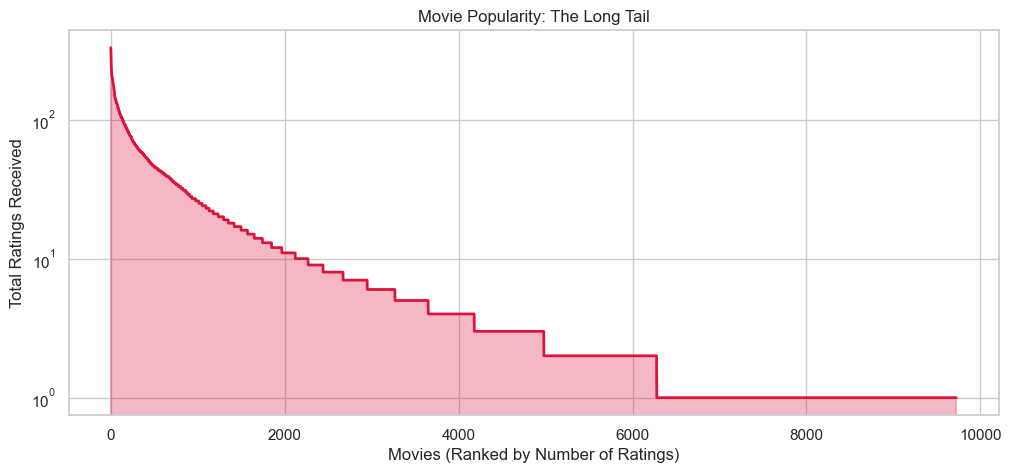

In [14]:
movie_rating_counts = df['movieId'].value_counts()
plt.figure(figsize=(12, 5))
plt.plot(movie_rating_counts.values, color='crimson', linewidth=2)
plt.fill_between(range(len(movie_rating_counts)), movie_rating_counts.values, color='crimson', alpha=0.3)
plt.title('Movie Popularity: The Long Tail')
plt.xlabel('Movies (Ranked by Number of Ratings)')
plt.ylabel('Total Ratings Received')
# Log scale helps visualize the extreme drop-off
plt.yscale('log') 
plt.show()

By observing the curve, we can identify two major groups of analyzed movies:
1. The blockbusters (the head): A small percentage of movies on the far left monopolize the majority of ratings. 
2. The niche (the long tail): As we move to the right, the curve drops off. Thousand of movies have fever than 10 ratings. The long flat line at the bottom right indicates that ma massice portion of movies in our dataset has only 1 rating.

Conclusion for further work:
We should build a Hybrid Ensemble Model rather than rely purely on Collaborative Filtering. Standard matrix factorization works well for the "head" of the curve because it has enough overlapping user data to calculate similarities. For the tail, our model has to fall back on the Content-Based Filtering, relying on data like genres, release years and tags, to find similarities based on the content of the film, rather than user behavior. 

In [15]:
print(f"Median ratings per movie: {movie_rating_counts.median()}")
print(f"Movies with < 5 ratings: {(movie_rating_counts < 5).sum()} (Cold Start Items)")

Median ratings per movie: 3.0
Movies with < 5 ratings: 6074 (Cold Start Items)


While the total number of ratings in the dataset may be high, the median number of ratings per movie is exactly 3.0. This means that fully $50\%$ of our entire movie catalog has 3 or fewer ratings. We identified exactly 6,074 movies with fewer than 5 ratings. In the context of Matrix Factorization, 5 ratings is generally considered the absolute minimum threshold required to calculate feature vectors.

#### User activity

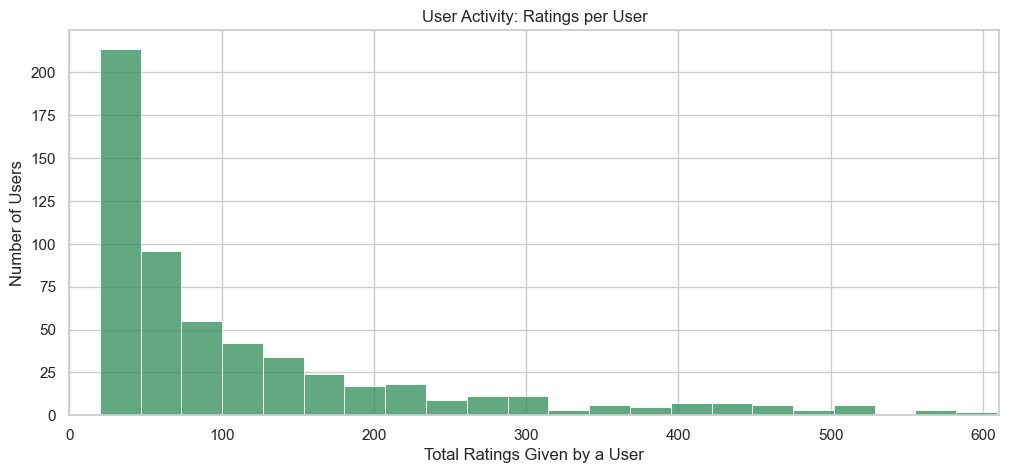

In [16]:
user_rating_counts = df['userId'].value_counts()
plt.figure(figsize=(12, 5))
sns.histplot(user_rating_counts, bins=100, color='seagreen', kde=False)
plt.title('User Activity: Ratings per User')
plt.xlabel('Total Ratings Given by a User')
plt.ylabel('Number of Users')
# Limit x-axis to zoom in on the majority of users, ignoring the extreme outliers for the plot
plt.xlim(0, user_rating_counts.quantile(0.95)) 
plt.show()

This right-skewed histogram illustrates the distribtuion of engagement across our user base. The massive spike on the far left shows that the vast majority of users are casual raters. Most users rate between 20 and 50 movies and then stop interacting with the platform. As we move to the right, the distribution trails off into a long tail of "power users." While few in number, these users have rated hundreds of movies.

Conclusion for further work:
Power users can dominate the model's training, skewing global recommendations away from the tastes of majority. To prevent this, we have to normalize the matrix by subtracting each user's average rating from their scores.

In [17]:
print(f"Median ratings per user: {user_rating_counts.median()}")
print(f"Users with < 20 ratings: {(user_rating_counts < 20).sum()} (Cold Start Users)")

Median ratings per user: 70.5
Users with < 20 ratings: 0 (Cold Start Users)


The fact that exactly 0 users have fewer than 20 ratings indicates that this dataset was pre-filtered by its creators. Every single user in our matrix has a guaranteed minimum of 20 interactions. Therefore we do not need to build a fallback mechanism for users.

#### Distribution of movie release years

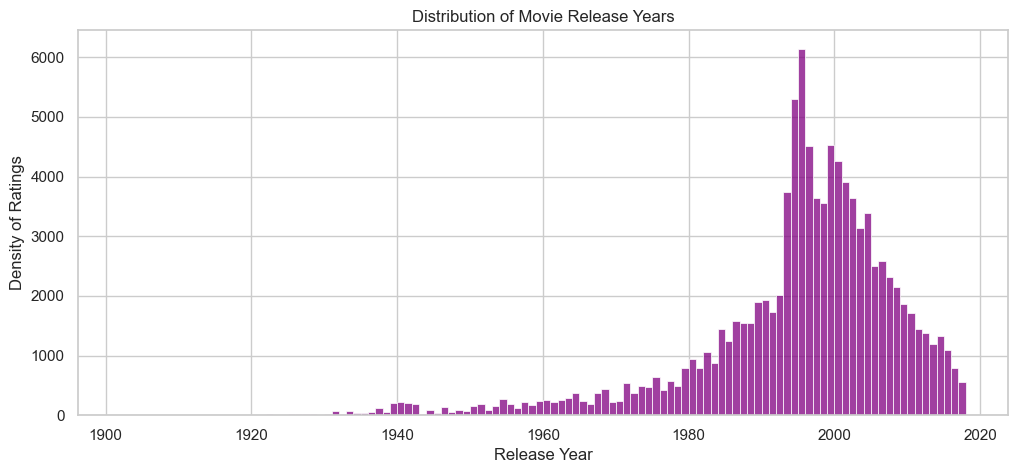

In [18]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='release_year', bins=int(df['release_year'].max() - df['release_year'].min()), color='purple')
plt.title('Distribution of Movie Release Years')
plt.xlabel('Release Year')
plt.ylabel('Density of Ratings')
plt.show()

This histogram reveals a severe chronological imbalance in our movie catalogue:
* The vast majority of user interactions are clustered around movies released between 1990 and 2010, peaking sharply around 1995.
* Movies released before 1980 receive very little overall engagement, forming a long, flat tail on the left.

Implications for our model:
Because standard CF favors items with dense interactions, the model will naturally default to recommending 90s and 2000s. We must use `release_year` as a core feature in our Content-Based pipeline. Instead of treating it as a continuous integer, we should bin these years into categorical "eras", like: "classics", "80s", "90s", "modern". This allows the embedding layer to explicitly learn if a user is a "classic film buff," helping older movies surface despite their lower overall rating volume.

### **Bivariate analysis (interactions)**

#### Movie quality vs popularity

In [19]:
movie_stats = df.groupby('title_clean').agg(
    rating_count=('rating', 'count'),
    rating_mean=('rating', 'mean')
).reset_index()
movie_stats_filtered = movie_stats[movie_stats['rating_count'] > 20]

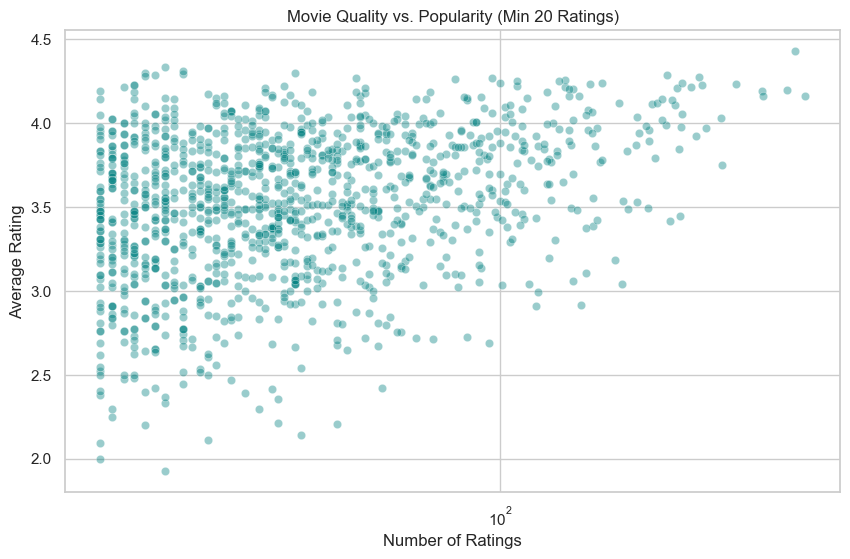

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=movie_stats_filtered, x='rating_count', y='rating_mean', alpha=0.4, color='teal')
plt.title('Movie Quality vs. Popularity (Min 20 Ratings)')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.xscale('log') # Log scale because of the long tail
plt.show()

This scatterplot visualizes two distinct phenomena:
1. Movies with fewer ratings (on the left) have massive variance—their averages range wildly from 2.0 to 4.5. A movie with only 20 ratings can easily be skewed by a few harsh or enthusiastic reviews.
2. As the number of ratings increases (moving right), the variance shrinks, and the average score trends upward. Highly popular movies are almost universally well-rated.

Architectural implications:
Because popular movies are highly rated, a CF model will naturally default to recommending the top-right quadrant. This creates a feedback loop where the model only recommends blockbusters. We cannot trust the raw average rating of a low-interaction movie. If we use item averages as features in our model, we must apply regularization (like Bayesian Smoothing) to pull the averages of low-count movies closer to gloval mean. Also, when we test our model later, standard accuracy metrics like RMSE will be misleadingly high if the model just guesses popular movies. We must include metrics like Coverage or Novelty to ensure the model is actually exploring the catalogue.

#### User bias

In [21]:
user_stats = df.groupby('userId').agg(
    rating_mean=('rating', 'mean'),
    rating_count=('rating', 'count')
).reset_index()

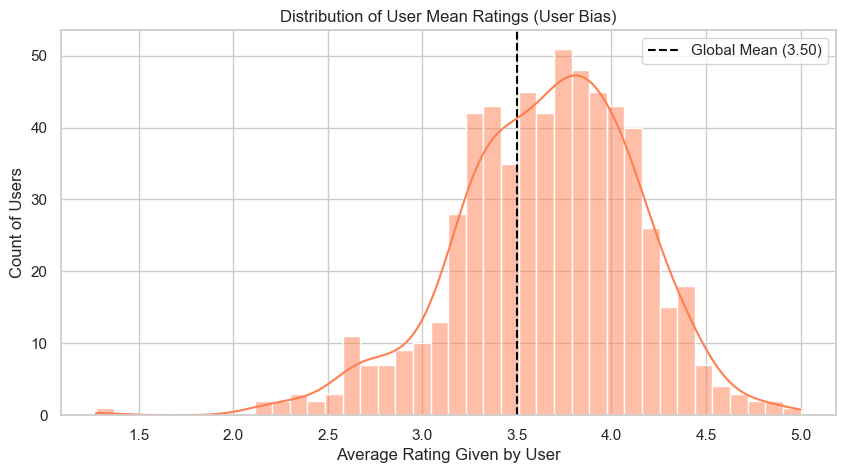

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(user_stats['rating_mean'], bins=40, color='coral', kde=True)
plt.title('Distribution of User Mean Ratings (User Bias)')
plt.xlabel('Average Rating Given by User')
plt.ylabel('Count of Users')
plt.axvline(df['rating'].mean(), color='black', linestyle='--', label=f'Global Mean ({df["rating"].mean():.2f})')
plt.legend()
plt.show()

While the global mean sits at 3.50, the peak of our distribution is actually higher (closer to 3.7 or 3.8). Furthermore, we have distinct tails: the harsh critics, who average a 2.5, and enthusiastic users, who average a 4.5.

Architectural implications:
A raw rating of 3.5 means something entirely different depending on who gave it. For a harsh critic this is a very high score, but for an enthusiastic user this means they disliked the film. This indicates the importance of normalization. By subtracting a user's personal mean from their raw ratings, we convert absolute scores into relative deviations. This ensures the model learns true preference patterns.

#### Genre performance

In [23]:
# We need to drop missing genres and explode the pipe-separated strings again
genres_df = df.dropna(subset=['genres']).copy()
genres_df['genres'] = genres_df['genres'].str.split('|')
genres_exploded = genres_df.explode('genres')

In [25]:
genre_stats = genres_exploded.groupby('genres').agg(
    rating_mean=('rating', 'mean'),
    rating_count=('rating', 'count')
).reset_index()
genre_stats = genre_stats[genre_stats['rating_count'] > 1000].sort_values('rating_mean', ascending=False)

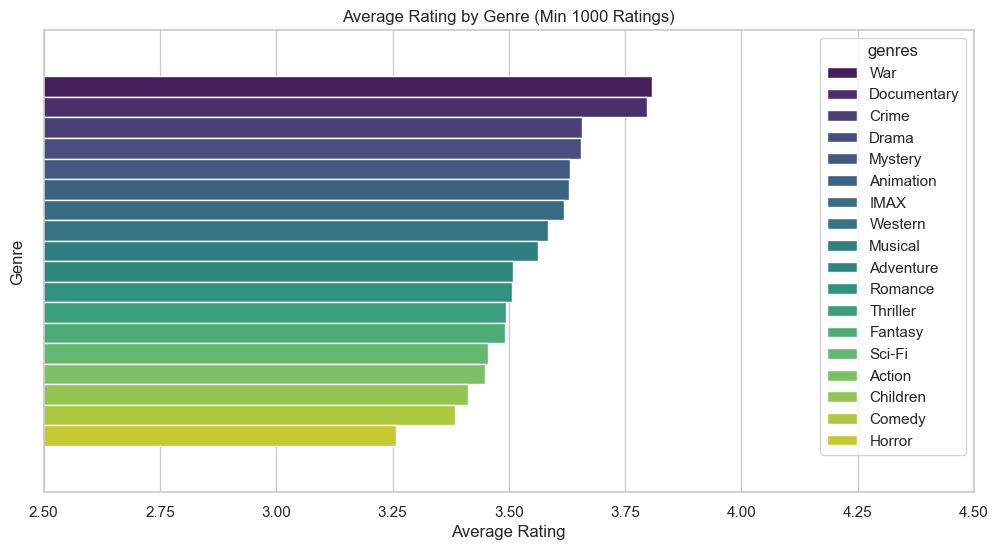

In [28]:
plt.figure(figsize=(12, 6))
sns.barplot(data=genre_stats, x='rating_mean', hue='genres', palette='viridis')
plt.title('Average Rating by Genre (Min 1000 Ratings)')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.xlim(2.5, 4.5) # Zoom in to see the differences clearly
plt.show()

* Serious, historical, or fact-based genres—specifically War and Documentary—dominate the top of the chart with averages near 3.8. Users fundamentally rate these higher, likely viewing them as "important" cinema.
* Conversely, pure entertainment genres like Comedy and Horror sit at the absolute bottom (averaging 3.25 - 3.3). A Horror fan might watch and enjoy a slasher film, but they will still rate it a 3.0 simply because of the genre's inherent stigma.

Implications for our model:
A raw score of $3.5$ means something entirely different depending on the genre. A $3.5$ is a remarkably high score for a Horror film, but a disappointingly low score for a War documentary. Because movies often span multiple genres, we must represent them using Multi-Hot Encoding. Passing these encoded genres through an embedding layer will allow the neural network to explicitly learn and neutralize these biases.

### **Temporal dynamics**

#### Platform activity over time

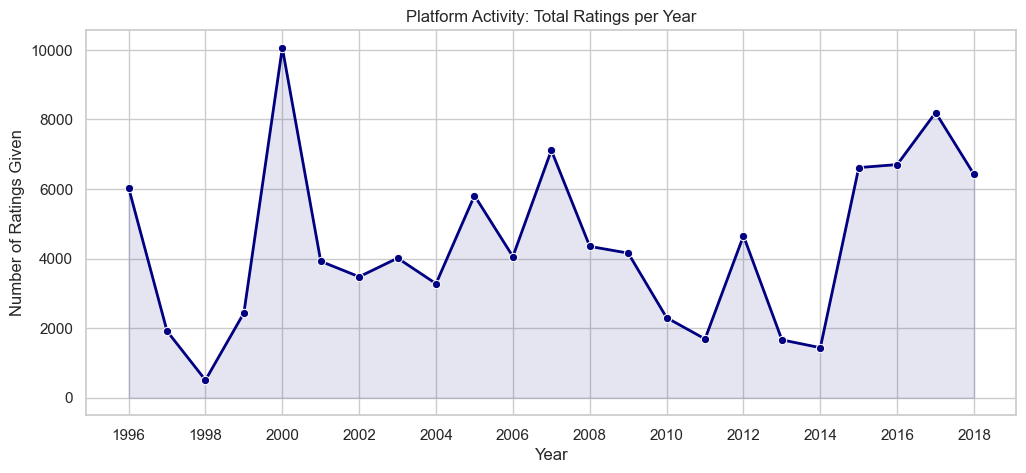

In [29]:
yearly_volume = df.groupby('rating_year').size()

plt.figure(figsize=(12, 5))
sns.lineplot(x=yearly_volume.index, y=yearly_volume.values, marker='o', color='navy', linewidth=2)
plt.fill_between(yearly_volume.index, yearly_volume.values, color='navy', alpha=0.1)
plt.title('Platform Activity: Total Ratings per Year')
plt.xlabel('Year')
plt.ylabel('Number of Ratings Given')
# Ensure x-axis shows integer years
plt.xticks(range(int(yearly_volume.index.min()), int(yearly_volume.index.max())+1, 2)) 
plt.show()

* There are massive spikes in data collection (notably around the year 2000 and again climbing towards 2018) separated by periods of very low interaction (such as 1998 and 2014).
* A model trained blindly on this entire dataset will naturally optimize for the user preferences and movie trends that were popular during that massive year-2000 spike, simply due to the volume of data.

Architectural implications:
* We cannot use a standard random 80/20 train/test split. Random splitting causes data leakage, because the model would use a user's 2018 ratings to predict their 2000 ratings, which is impossible in the real world. We must implement a Time-Based Split.
* A user's taste in 2000 is likely very different from their taste in 2018. To account for shifting preferences, we should introduce a Time Decay Function into our matrix factorization, assigning higher confidence weights to recent ratings and lower weights to older interactions.

#### Rating drift

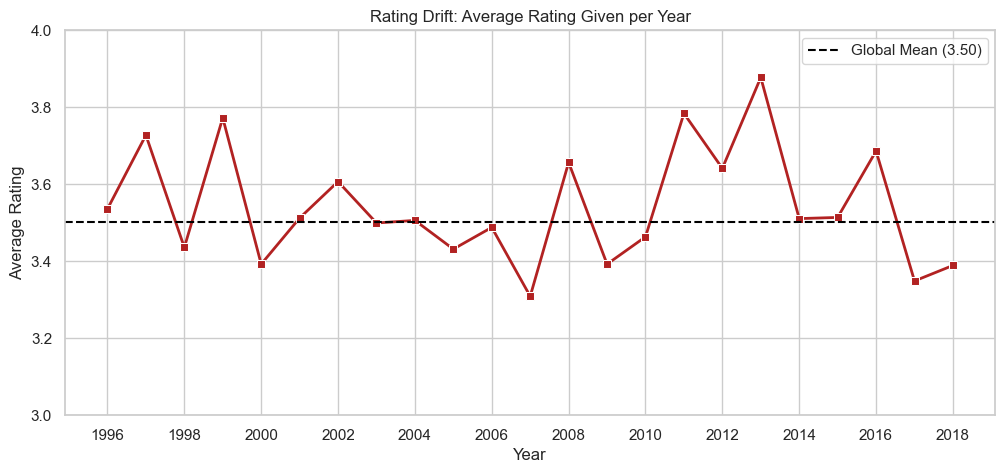

In [30]:
yearly_avg = df.groupby('rating_year')['rating'].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values, marker='s', color='firebrick', linewidth=2)
plt.title('Rating Drift: Average Rating Given per Year')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.ylim(3.0, 4.0) # Keep Y-axis tightly bounded to visualize the drift clearly
plt.axhline(df['rating'].mean(), color='black', linestyle='--', label=f'Global Mean ({df["rating"].mean():.2f})')
plt.xticks(range(int(yearly_avg.index.min()), int(yearly_avg.index.max())+1, 2))
plt.legend()
plt.show()

#### Day of week activity

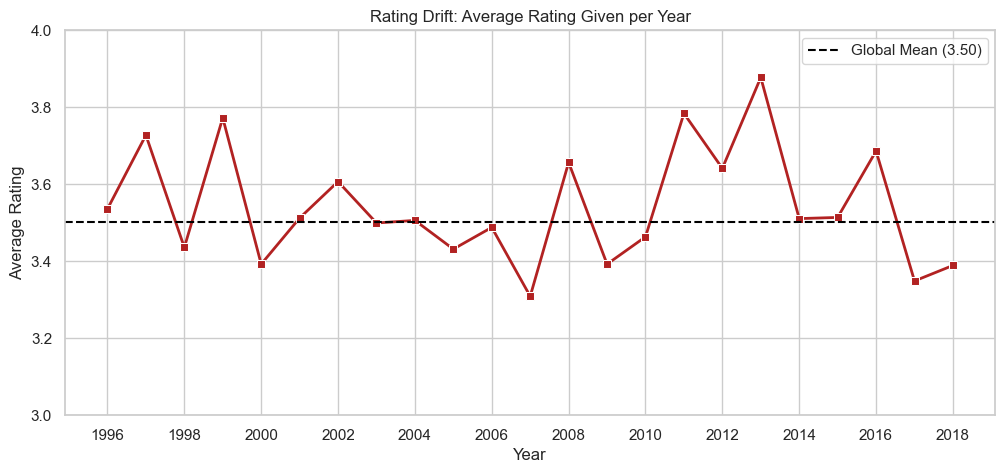

In [31]:
yearly_avg = df.groupby('rating_year')['rating'].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values, marker='s', color='firebrick', linewidth=2)
plt.title('Rating Drift: Average Rating Given per Year')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.ylim(3.0, 4.0) # Keep Y-axis tightly bounded to visualize the drift clearly
plt.axhline(df['rating'].mean(), color='black', linestyle='--', label=f'Global Mean ({df["rating"].mean():.2f})')
plt.xticks(range(int(yearly_avg.index.min()), int(yearly_avg.index.max())+1, 2))
plt.legend()
plt.show()